<a href="https://colab.research.google.com/github/MiguelFigueroa02/1820-machine-learning-lidiando-con-datos-de-muchas-dimensiones/blob/main/dimensionality_reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning: Lidiando con datos de muchas dimensiones

Cuando trabajamos con datos que contienen muchas dimensiones, lo recomendable es tomar dichos datos y transformarlos de modo que se ajusten a un espacio dimensional menor asegurándonos de que el espacio dimensional resultante mantenga las propiedades que mejor caracterizan a los datos originales, garantizando su dimensión intrínseca.


En este notebook, estaremos aprendiendo varias estrategias para lidiar con la alta dimensionalidad en el modelaje de aprendizaje de máquina.


El dataset empleado en el desarrollo de este proyecto es un dataset ficticio, llamado a ```aluracare.csv```, adaptado a nuestro contexto, tomando como referencia el siguiente dataset:  

*Dataset:* https://www.kaggle.com/uciml/breast-cancer-wisconsin-data

# 1. Datos con muchas dimensiones

##### *https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html*

*https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html*

*https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html*

*https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html*

In [2]:
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [3]:
url = 'https://raw.githubusercontent.com/MiguelFigueroa02/1820-machine-learning-lidiando-con-datos-de-muchas-dimensiones/refs/heads/main/aluracare.csv'
dataset = pd.read_csv(url)
dataset.head(3)

,id,diagnostico,examen_1,examen_2,examen_3,examen_4,examen_5,examen_6,examen_7,examen_8,...,examen_24,examen_25,examen_26,examen_27,examen_28,examen_29,examen_30,examen_31,examen_32,examen_33
0,842302,M,17.99,10.38,122.8,103.78,1001.0,0.11840,0.27760,0.3001,...,184.6,2019.0,0.1622,0.6656,0.7119,0.786,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.9,103.78,1326.0,0.08474,0.07864,0.0869,...,158.8,1956.0,0.1238,0.1866,0.2416,0.786,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.0,103.78,1203.0,0.10960,0.15990,0.1974,...,152.5,1709.0,0.1444,0.4245,0.4504,0.786,0.2430,0.3613,0.08758,NaN


In [4]:
dataset.shape

(569, 35)

In [5]:
dataset.diagnostico.value_counts()

,count
diagnostico,
B,357
M,212


In [6]:
dataset.isna().sum()

,0
id,0
diagnostico,0
examen_1,0
examen_2,0
examen_3,0
examen_4,0
examen_5,0
examen_6,0
examen_7,0
examen_8,0


In [7]:
dataset.drop(columns=['id','examen_33'],axis= 1, inplace=True)

In [8]:
dataset.diagnostico.replace('M', 1, inplace=True)
dataset.diagnostico.replace('B', 0, inplace=True)
dataset.head()

/tmp/ipykernel_4440/3991036440.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset.diagnostico.replace('M', 1, inplace=True)
/tmp/ipykernel_4440/3991036440.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

,diagnostico,examen_1,examen_2,examen_3,examen_4,examen_5,examen_6,examen_7,examen_8,examen_9,...,examen_23,examen_24,examen_25,examen_26,examen_27,examen_28,examen_29,examen_30,examen_31,examen_32
0,1,17.99,10.38,122.80,103.78,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.786,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,103.78,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.786,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,103.78,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.786,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,103.78,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.786,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,103.78,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.786,0.1625,0.2364,0.07678


In [9]:
X = dataset.drop(columns='diagnostico',axis= 1)
X_std = StandardScaler().fit_transform(X)
y = dataset.diagnostico

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_std, y, random_state=42, test_size=0.30)

In [11]:
logistic = LogisticRegression(C=100, n_jobs=-1)
logistic.fit(X_train, y_train)

LogisticRegression(C=100, n_jobs=-1)

In [12]:
logistic.score(X_test, y_test)

0.9590643274853801

In [13]:
logistic = LogisticRegression(C=1, n_jobs=-1)
logistic.fit(X_train, y_train)

LogisticRegression(C=1, n_jobs=-1)

In [14]:
logistic.score(X_test, y_test)

0.9824561403508771

In [15]:
forest = RandomForestClassifier()
forest.fit(X_train, y_train)

RandomForestClassifier()

In [16]:
forest.score(X_test, y_test)

0.9707602339181286

# 2. Avanzando y explorando los datos

##### *https://seaborn.pydata.org/introduction.html*
*https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.html*

In [17]:
datos= pd.concat([y,X], axis=1)
datos = pd.melt(datos, id_vars='diagnostico', var_name='examenes',value_name='resultados')
datos.head()

,diagnostico,examenes,resultados
0,1,examen_1,17.99
1,1,examen_1,20.57
2,1,examen_1,19.69
3,1,examen_1,11.42
4,1,examen_1,20.29


In [18]:
datos.shape

(18208, 3)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31],
 [Text(0, 0, 'examen_1'),
  Text(1, 0, 'examen_2'),
  Text(2, 0, 'examen_3'),
  Text(3, 0, 'examen_4'),
  Text(4, 0, 'examen_5'),
  Text(5, 0, 'examen_6'),
  Text(6, 0, 'examen_7'),
  Text(7, 0, 'examen_8'),
  Text(8, 0, 'examen_9'),
  Text(9, 0, 'examen_10'),
  Text(10, 0, 'examen_11'),
  Text(11, 0, 'examen_12'),
  Text(12, 0, 'examen_13'),
  Text(13, 0, 'examen_14'),
  Text(14, 0, 'examen_15'),
  Text(15, 0, 'examen_16'),
  Text(16, 0, 'examen_17'),
  Text(17, 0, 'examen_18'),
  Text(18, 0, 'examen_19'),
  Text(19, 0, 'examen_20'),
  Text(20, 0, 'examen_21'),
  Text(21, 0, 'examen_22'),
  Text(22, 0, 'examen_23'),
  Text(23, 0, 'examen_24'),
  Text(24, 0, 'examen_25'),
  Text(25, 0, 'examen_26'),
  Text(26, 0, 'examen_27'),
  Text(27, 0, 'examen_28'),
  Text(28, 0, 'examen_29'),
  Text(29, 0, 'examen_30

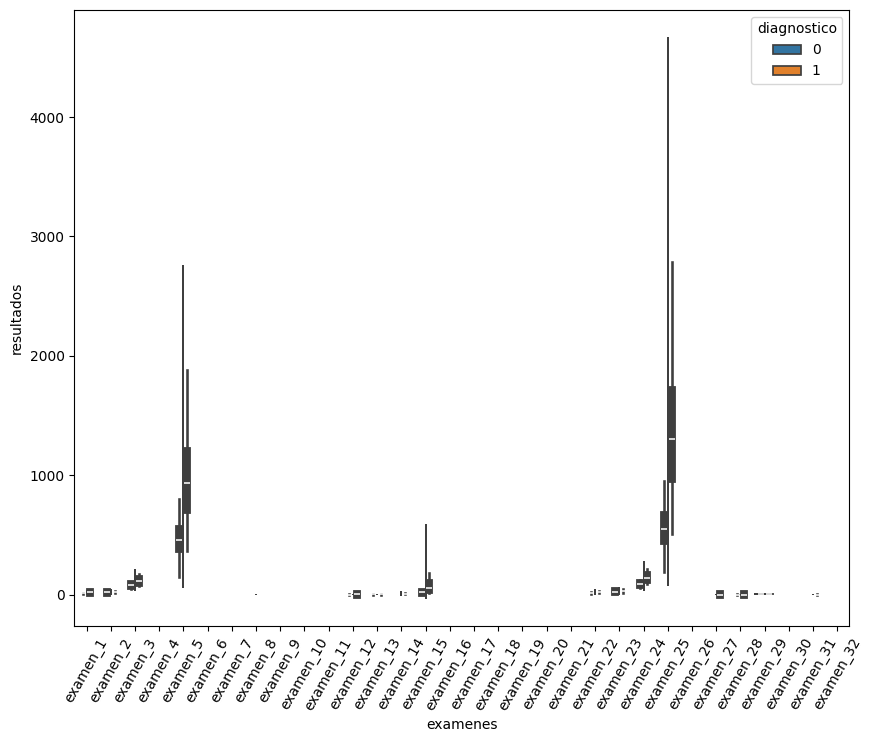

In [19]:
plt.figure(figsize=(10,8))
sns.violinplot(data=datos,x='examenes' ,y='resultados' , hue='diagnostico', split=True)
plt.xticks(rotation=60)

In [20]:
X1= pd.DataFrame(X_std, columns= X.keys())

def violin(inicio, fin):
  datos= pd.concat([y,X1.iloc[:,inicio:fin]], axis=1)
  datos = pd.melt(datos, id_vars='diagnostico', var_name='examenes',value_name='resultados')
  plt.figure(figsize=(10,8))
  sns.violinplot(data=datos,x='examenes' ,y='resultados' , hue='diagnostico', split=True)
  plt.xticks(rotation=60)

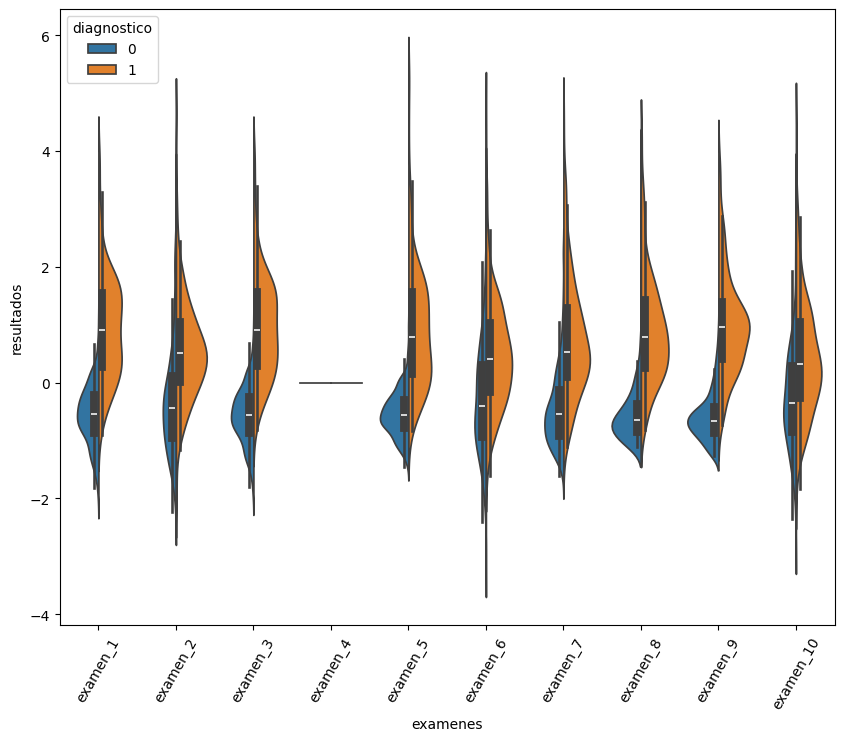

In [21]:
violin(0,10)

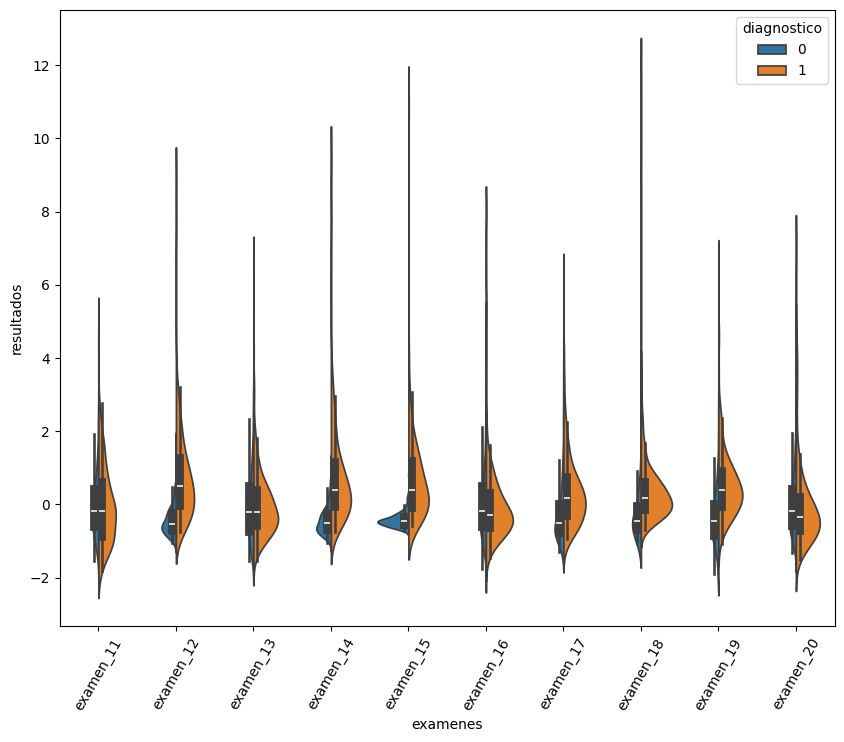

In [22]:
violin(10,20)

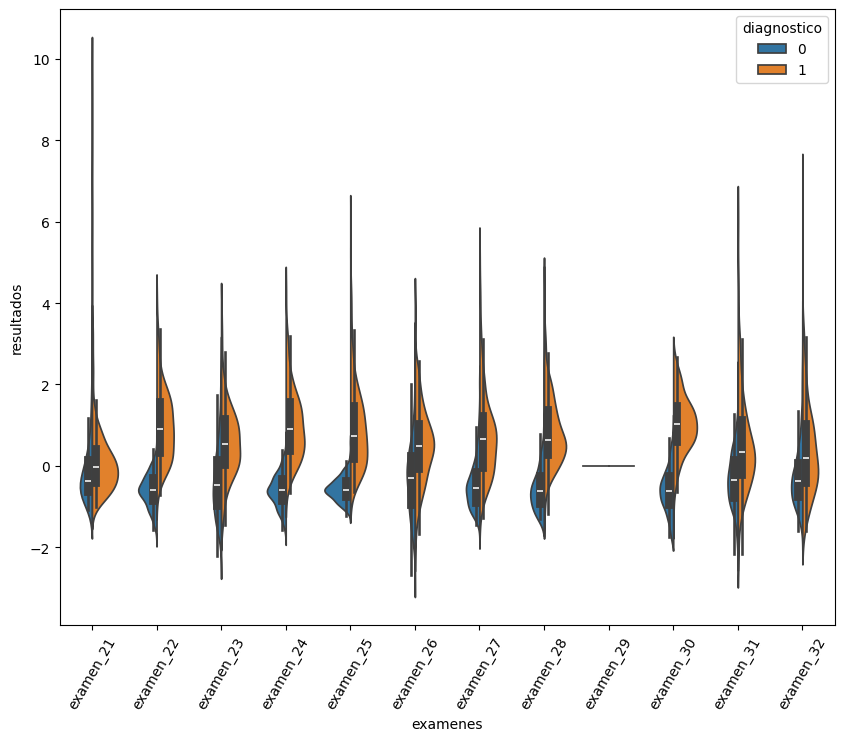

In [23]:
violin(20,32)

In [24]:
X1.examen_29

,examen_29
0,1.110223e-16
1,1.110223e-16
2,1.110223e-16
3,1.110223e-16
4,1.110223e-16
...,...
564,1.110223e-16
565,1.110223e-16
566,1.110223e-16
567,1.110223e-16


In [26]:
X2 = X1.drop(columns=['examen_29','examen_4'], axis=1)

In [29]:
def puntaje(resultados):
  X_train, X_test, y_train, y_test = train_test_split(resultados, y, random_state=42, test_size=0.30)
  logistic= LogisticRegression(C=1, n_jobs=-1)
  logistic.fit(X_train,y_train)
  return f'La exactitud es: {round(logistic.score(X_test, y_test)*100,2)}%'


In [31]:
print(puntaje(X1))

La exactitud es: 98.25%


In [32]:
print(puntaje(X2))

La exactitud es: 98.25%


# 3. Datos correlacionados

In [33]:
X2.corr()

,examen_1,examen_2,examen_3,examen_5,examen_6,examen_7,examen_8,examen_9,examen_10,examen_11,...,examen_22,examen_23,examen_24,examen_25,examen_26,examen_27,examen_28,examen_30,examen_31,examen_32
examen_1,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
examen_2,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
examen_3,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
examen_5,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
examen_6,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
examen_7,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
examen_8,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
examen_9,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
examen_10,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
examen_11,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.253691,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


<Axes: >

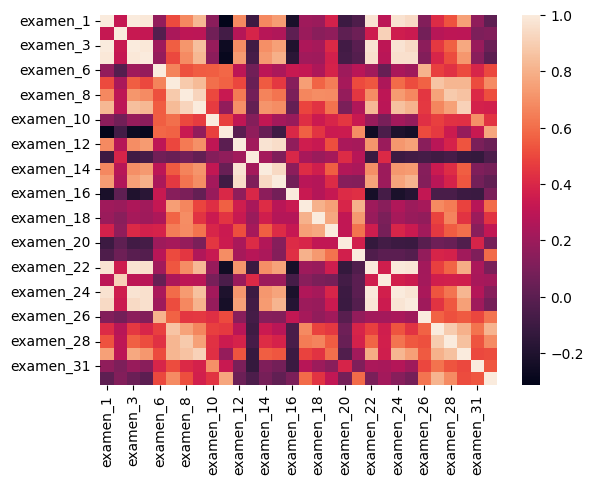

In [34]:
sns.heatmap(X2.corr())

<Axes: >

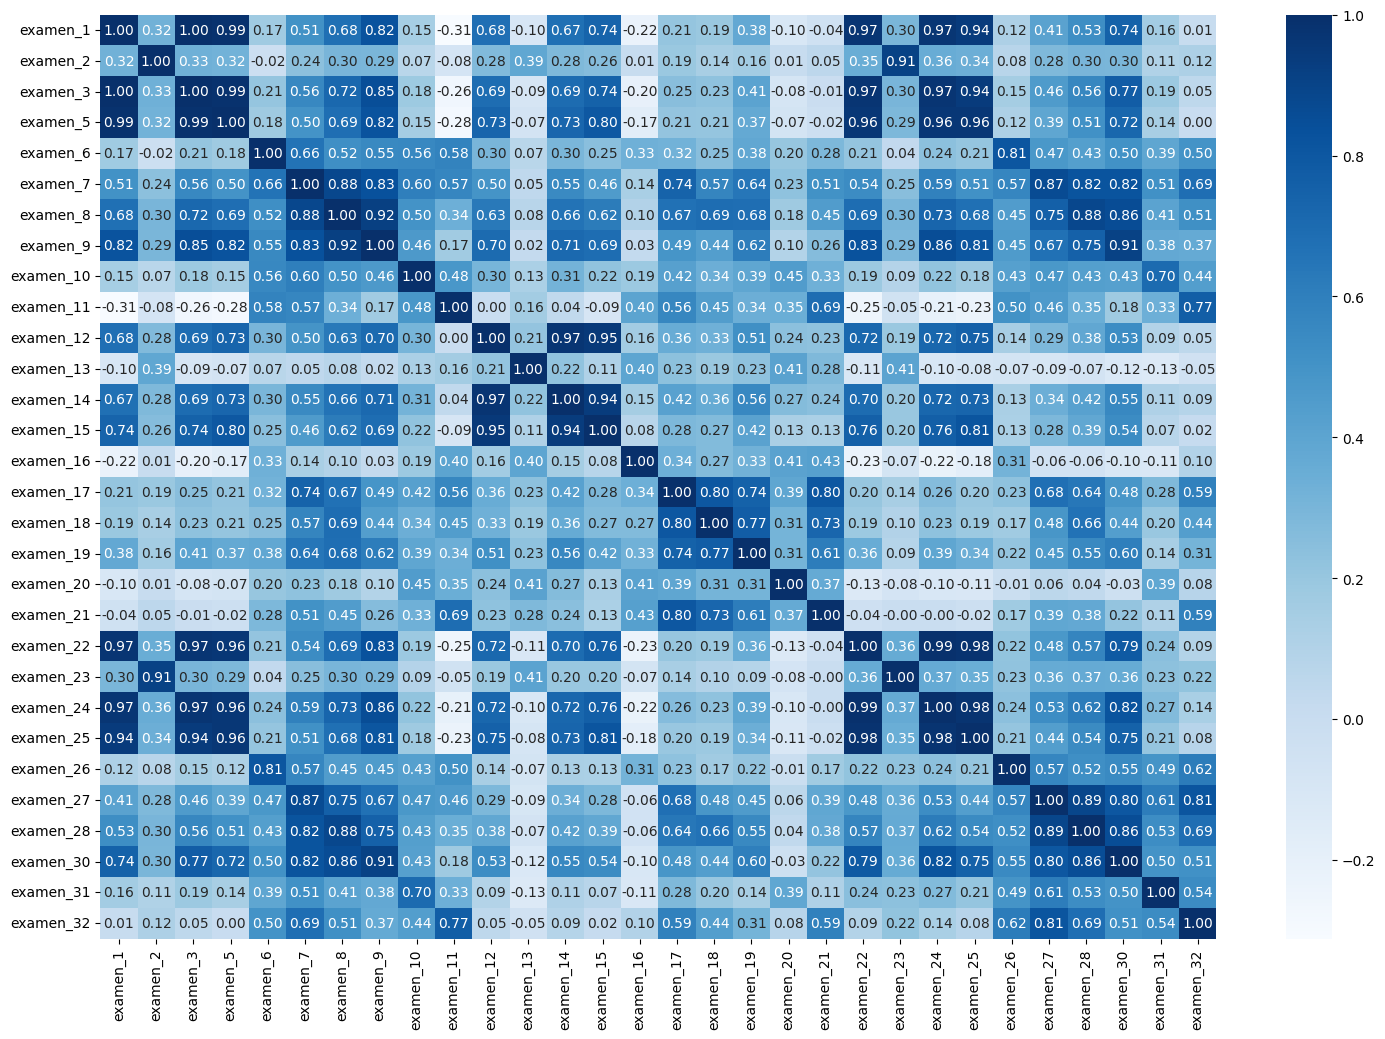

In [36]:
plt.figure(figsize=(18,12))
sns.heatmap(X2.corr(),annot=True, fmt='.2f', cmap='Blues')

In [38]:
alta_corr = X2.corr()[X2.corr() > 0.99]
alta_corr

,examen_1,examen_2,examen_3,examen_5,examen_6,examen_7,examen_8,examen_9,examen_10,examen_11,...,examen_22,examen_23,examen_24,examen_25,examen_26,examen_27,examen_28,examen_30,examen_31,examen_32
examen_1,1.000000,NaN,0.997855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
examen_2,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
examen_3,0.997855,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
examen_5,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
examen_6,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
examen_7,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
examen_8,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
examen_9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
examen_10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
examen_11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
alta_corr.sum()

,0
examen_1,1.997855
examen_2,1.000000
examen_3,1.997855
examen_5,1.000000
examen_6,1.000000
examen_7,1.000000
examen_8,1.000000
examen_9,1.000000
examen_10,1.000000
examen_11,1.000000


In [40]:
X3 = X2.drop(columns=['examen_3','examen_24'])
X3.head()

,examen_1,examen_2,examen_5,examen_6,examen_7,examen_8,examen_9,examen_10,examen_11,examen_12,...,examen_21,examen_22,examen_23,examen_25,examen_26,examen_27,examen_28,examen_30,examen_31,examen_32
0,1.097064,-2.073335,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,2.489734,...,0.907083,1.886690,-1.359293,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,0.499255,...,-0.099444,1.805927,-0.369203,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,1.228676,...,0.293559,1.511870,-0.023974,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,0.326373,...,2.047511,-0.281464,0.133984,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,1.270543,...,0.499328,1.298575,-1.466770,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [43]:
puntaje(X3)

'La exactitud es: 98.25%'

# 4. Automatizando la selección de los datos

##### *https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html*

*https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.chi2.html*

*https://scikit-learn.org/stable/modules/generated/sklearn.metrics.plot_confusion_matrix.html*

*https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html*

In [44]:
from sklearn.feature_selection import SelectKBest, chi2

kbest = SelectKBest(score_func=chi2,k=5)

In [45]:
X4 = X.drop(columns=['examen_29','examen_4','examen_3','examen_24'], axis=1)

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X4, y, random_state=42, test_size=0.30)

In [47]:
kbest.fit(X_train, y_train)

SelectKBest(k=5, score_func=<function chi2 at 0x7d2425dd4cc0>)

In [48]:
kbest_train= kbest.transform(X_train)
kbest_test = kbest.transform(X_test)
logistic= LogisticRegression()
logistic.fit(kbest_train, y_train)

LogisticRegression()

In [57]:
y_prob = logistic.predict(kbest_test)

In [58]:
y_prob

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0])

In [51]:
print(f'La exactitud utilizando kbest es: {round(logistic.score(kbest_test, y_test)*100, 2)}%')

La exactitud utilizando kbest es: 96.49%


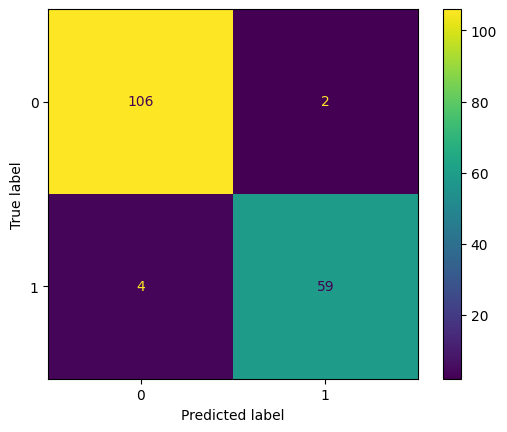

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(logistic, kbest_test, y_test)

In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

In [63]:
def seleccion(train, test):
  model = logistic.fit(train, y_train)
  print(f'La tasa de acierto: {round(recall_score(y_test, model.predict(test))*100,2)}%')
  print(f'La precision: {round(precision_score(y_test, model.predict(test))*100,2)}%')
  print(f'El valor f es : {round(f1_score(y_test, model.predict(test))*100,2)}%')
  print(f'La exactitud: {round(accuracy_score(y_test, model.predict(test))*100,2)}%')

In [64]:
seleccion(kbest_train, kbest_test)

La tasa de acierto: 93.65%
La precision: 96.72%
El valor f es : 95.16%
La exactitud: 96.49%


In [65]:
from sklearn.feature_selection import RFE

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X3, y, random_state=42, test_size=0.30)
logistic = LogisticRegression()
logistic.fit(X_train, y_train)
rfe = RFE(estimator=logistic, n_features_to_select=5, step=1)
rfe.fit(X_train, y_train)

RFE(estimator=LogisticRegression(), n_features_to_select=5)

In [67]:
rfe_train = rfe.transform(X_train)
rfe_test = rfe.transform(X_test)

seleccion(rfe_train, rfe_test)

La tasa de acierto: 96.83%
La precision: 95.31%
El valor f es : 96.06%
La exactitud: 97.08%


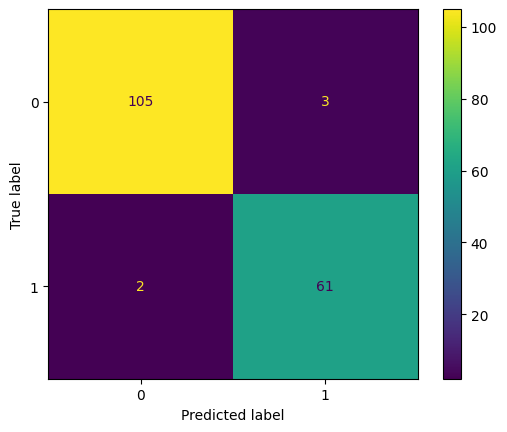

In [68]:
ConfusionMatrixDisplay.from_estimator(logistic, rfe_test, y_test)

In [69]:
rfe.support_

array([False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False,  True,  True,  True, False, False, False,  True, False,
       False])

In [70]:
X3.columns[rfe.support_]

Index(['examen_12', 'examen_22', 'examen_23', 'examen_25', 'examen_30'], dtype='object')

# 5. Visualizando los datos en el plano

##### *https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFECV.html*

*https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html*

*https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html*